In [23]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib as mpl

In [24]:
class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [25]:
from src.various import clock

In [26]:
import src.compute.stats as stats_module
# from data import b_naive, b_memory

import importlib
import src.plot.tracks.reconstruct as reconstruct_module
import src.plot.time as time_module
import src.batch.tree as batch_tree_module
import src.loader.load as load_module


In [27]:
importlib.reload(stats_module)

stats = stats_module.stats

In [28]:
importlib.reload(load_module)

load_data = load_module.load_data

data = load_data(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\mem_cxcl12\#memory-cxcl12#BC39#Stablized_spots.csv", retain=['POSITION_Z'], split_filename=True, split_filename_delimiter='#', split_filename_position=2)

data

track_id,time_point,x_coordinate,y_coordinate,POSITION_Z,set
f64,f64,f64,f64,f64,str
0.0,240.0,517.653549,180.677172,0.0,"""BC39"""
0.0,300.0,503.120148,183.276014,0.0,"""BC39"""
0.0,360.0,499.649021,198.269841,0.0,"""BC39"""
0.0,480.0,506.060802,224.605518,0.0,"""BC39"""
0.0,60.0,504.683266,196.063563,0.0,"""BC39"""
…,…,…,…,…,…
734.0,3480.0,0.0,479.82254,0.0,"""BC39"""
735.0,3420.0,0.0,496.062688,0.0,"""BC39"""
735.0,3480.0,0.0,488.680803,0.0,"""BC39"""


In [29]:
data.metadata.get()

{'spatialunits': 'μm', 'timeunits': 's', 'timeinterval': 60.0, 'nframes': 60}

In [30]:
importlib.reload(batch_tree_module)

make_tree = batch_tree_module.make_tree

tree = make_tree("C:\\Users\\modri\\Desktop\\Lab\\Peregrin project\\Tree test")
# tree = make_tree("C:\\Users\\modri\\Desktop\\Lab\\Peregrin project")

tree.show()

tree_dict = tree.get()
tree_list = tree.get(type='list')


tree_dict = tree.get()

data = load_data(tree_dict)


Tree test
└── 15-5-262
    ├── 1-abs
    │   ├── #memory-ctr#BC39#Stablized_spots.csv
    │   ├── #memory-ctr#BC42 (fresh)#Stablized_spots.csv
    │   ├── #memory-ctr#BC42#Stablized_spots.csv
    │   └── #memory-ctr#BC43#Stablized_spots.csv
    ├── 2-abs
    │   ├── #memory-cxcl12#BC39#Stablized_spots.csv
    │   ├── #memory-cxcl12#BC42 (fresh)#Stablized_spots.csv
    │   ├── #memory-cxcl12#BC42#Stablized_spots.csv
    │   └── #memory-cxcl12#BC43#Stablized_spots.csv
    └── 3-abs
        ├── #memory-cxcl12-mu#BC39#Stablized_spots.csv
        ├── #memory-cxcl12-mu#BC42 (fresh)#Stablized_spots.csv
        ├── #memory-cxcl12-mu#BC42#Stablized_spots.csv
        └── #memory-cxcl12-mu#BC43#Stablized_spots.csv


C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin\src\loader\load.py:116: InputWarning: Inconsistent number of frames across input files -> found {59, 60}.
  self._check()


In [31]:
data

track_id,time_point,x_coordinate,y_coordinate,set,subset,group
f64,f64,f64,f64,str,str,str
0.0,240.0,1072.441598,693.055117,"""15-5-262""","""1-abs""","""#memory-ctr#BC39#Stablized_spo…"
0.0,1320.0,1093.351399,676.847641,"""15-5-262""","""1-abs""","""#memory-ctr#BC39#Stablized_spo…"
0.0,420.0,1104.689939,683.918605,"""15-5-262""","""1-abs""","""#memory-ctr#BC39#Stablized_spo…"
0.0,360.0,1093.743013,686.18834,"""15-5-262""","""1-abs""","""#memory-ctr#BC39#Stablized_spo…"
0.0,1020.0,1100.831004,674.251173,"""15-5-262""","""1-abs""","""#memory-ctr#BC39#Stablized_spo…"
…,…,…,…,…,…,…
161.0,3420.0,961.121458,874.015212,"""15-5-262""","""3-abs""","""#memory-cxcl12-mu#BC43#Stabliz…"
161.0,3480.0,958.596234,863.515861,"""15-5-262""","""3-abs""","""#memory-cxcl12-mu#BC43#Stabliz…"
161.0,3540.0,958.484827,860.742829,"""15-5-262""","""3-abs""","""#memory-cxcl12-mu#BC43#Stabliz…"


In [32]:
# stats.input_metadata.get()

In [33]:
import numpy as np
import pandas as pd


def craft_dummy_dataframe(
    n_tracks: int = 6,
    n_time_points: int = 100,
    seed: int | None = 20,
) -> pd.DataFrame:
    """
    Generate a synthetic dataset simulating cell trajectories,
    organised into 2 sets, each with 2 subsets.

    Cells perform a persistent random walk (correlated random walk) with
    per-cell speed and directional persistence, plus small positional noise,
    which mimics realistic migrating-cell behaviour.

    Returns a DataFrame with columns:
        'set', 'subset', 'track_id', 'time_point',
        'x_coordinate', 'y_coordinate'
    """
    rng = np.random.default_rng(seed)
    records = []

    sets = ['set_A', 'set_B']
    subsets = ['subset_1', 'subset_2']

    global_track_id = 0

    for set_name in sets:
        for subset_name in subsets:
            for _ in range(n_tracks):
                global_track_id += 1
                track_id = global_track_id

                # Each cell can appear/disappear at slightly different times
                start = rng.integers(0, n_time_points // 4)
                length = rng.integers(n_time_points // 2, n_time_points + 1)
                end = min(start + length, n_time_points)

                # Random starting position in a 2D field
                x, y = rng.uniform(0, 500), rng.uniform(0, 500)

                # Per-cell motility characteristics
                speed = rng.uniform(2.0, 8.0)          # mean step length
                persistence = rng.uniform(0.6, 0.98)   # directional memory (0-1)
                angle = rng.uniform(0, 2 * np.pi)      # initial heading

                for t in range(start, end):
                    records.append(
                        (set_name, subset_name, track_id, t, x, y)
                    )

                    # Update heading with persistence (correlated random walk)
                    angle += (1 - persistence) * rng.uniform(-np.pi, np.pi)

                    step = rng.normal(speed, speed * 0.2)
                    x += step * np.cos(angle) + rng.normal(0, 0.5)
                    y += step * np.sin(angle) + rng.normal(0, 0.5)

    df = pd.DataFrame(
        records,
        columns=[
            'set', 'subset', 'track_id',
            'time_point', 'x_coordinate', 'y_coordinate',
        ],
    )
    df = df.sort_values(
        ['set', 'subset', 'track_id', 'time_point']
    ).reset_index(drop=True)

    df['track_uid'] = df.groupby(['set', 'subset', 'track_id']).ngroup()

    return df


df = craft_dummy_dataframe()
df

,set,subset,track_id,time_point,x_coordinate,y_coordinate,track_uid
0,set_A,subset_1,1,22,230.573355,60.859846,0
1,set_A,subset_1,1,23,234.227119,60.628657,0
2,set_A,subset_1,1,24,239.168127,60.344644,0
3,set_A,subset_1,1,25,242.898700,57.809882,0
4,set_A,subset_1,1,26,245.228029,54.597547,0
...,...,...,...,...,...,...,...
1708,set_B,subset_2,24,95,165.663738,651.145494,23
1709,set_B,subset_2,24,96,160.947074,653.762386,23
1710,set_B,subset_2,24,97,151.214694,656.336399,23
1711,set_B,subset_2,24,98,146.936610,659.480518,23


In [34]:
importlib.reload(stats_module)

stats = stats_module.stats

def test_spots(categories: list[str] | None = None) -> pd.DataFrame:
    df = craft_dummy_dataframe()
    spots = stats.spots(df)

    columns =  ['track_id', 'time_point', 'x_coordinate', 'y_coordinate', 'frame', 'distance', 
                'cum_track_length', 'cum_track_displacement', 'cum_straightness_ratio', 'cum_speed_mean',
                'cum_mean_straight_line_speed', 'cum_forward_progression_linearity', 'direction', 
                'directional_change', 'cum_sum_directional_change', 'cum_mean_directional_change', 
                'cum_mean_directional_change_rate', 'cum_direction_mean', 'cum_direction_var']

    if categories is not None:
        if not isinstance(categories, list) or not all(isinstance(cat, str) for cat in categories):
            raise ValueError("categories must be a list of strings")
        columns += categories

    for col in columns:
        assert col in spots.columns, f"Column {col} is missing in spots DataFrame"

    return spots

spots = test_spots(['set', 'subset'])
spots

set,subset,track_id,time_point,x_coordinate,y_coordinate,track_uid,frame,distance,cum_track_length,cum_track_displacement,cum_straightness_ratio,cum_speed_mean,cum_mean_straight_line_speed,cum_forward_progression_linearity,direction,directional_change,cum_sum_directional_change,cum_mean_directional_change,cum_mean_directional_change_rate,cum_direction_mean,cum_direction_var
str,str,i64,i64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""set_A""","""subset_1""",1,22,230.573355,60.859846,0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""set_A""","""subset_1""",1,23,234.227119,60.628657,0,1,3.661071,3.661071,3.661071,1.0,3.661071,1.830535,0.5,-0.06319,null,null,null,null,-0.06319,0.0
"""set_A""","""subset_1""",1,24,239.168127,60.344644,0,2,4.949165,8.610235,8.6102,0.999996,4.305118,2.870067,0.666664,-0.057418,0.330747,0.330747,0.330747,0.110249,-0.060304,0.000004
"""set_A""","""subset_1""",1,25,242.8987,57.809882,0,3,4.510232,13.120467,12.697103,0.967733,4.373489,3.174276,0.725799,-0.596805,30.904621,31.235368,15.617684,3.904421,-0.237185,0.031728
"""set_A""","""subset_1""",1,26,245.228029,54.597547,0,4,3.96798,17.088447,15.93662,0.932596,4.272112,3.187324,0.746077,-0.943409,19.858979,51.094346,17.031449,3.40629,-0.41241,0.069341
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""set_B""","""subset_2""",24,95,165.663738,651.145494,23,73,6.204479,466.606803,433.355841,0.928739,6.391874,5.85616,0.916188,2.571644,18.846007,675.379179,9.380266,0.12676,1.639609,0.072347
"""set_B""","""subset_2""",24,96,160.947074,653.762386,23,74,5.393981,472.000784,436.290539,0.924343,6.378389,5.817207,0.912018,2.635058,3.633354,679.012533,9.301542,0.124021,1.651899,0.07746
"""set_B""","""subset_2""",24,97,151.214694,656.336399,23,75,10.067014,482.067798,439.679452,0.91207,6.427571,5.785256,0.900069,2.883033,14.207968,693.2205,9.367845,0.123261,1.665642,0.085232


In [35]:
importlib.reload(reconstruct_module)

reconstruct_tracks = reconstruct_module.reconstruct

# reconstruct_tracks(spots, display_uid=True, color='blue')

In [36]:
importlib.reload(stats_module)

stats = stats_module.stats

def test_tracks(categories: list[str] | None = None) -> pd.DataFrame:
    df = craft_dummy_dataframe()
    spots = stats.spots(df)
    tracks = stats.tracks(spots, categories=categories)

    columns = ['track_id', 'track_length', 'speed_min', 'speed_max', 'speed_mean', 'speed_sd', 
               'speed_median', 'x_location', 'y_location', 'max_distance_reached', 'track_start_frame', 
               'track_end_frame', 'mean_straight_line_speed', 
               'forward_progression_linearity', 'direction_mean', 'direction_var', 'mean_directional_change', 
               'mean_directional_change_rate', 'track_displacement', 'straightness_ratio', 'track_points']

    if categories is not None:
        if not isinstance(categories, list) or not all(isinstance(cat, str) for cat in categories):
            raise ValueError("categories must be a list of strings")
        columns += categories

    for col in columns:
        assert col in tracks.columns, f"Column {col} is missing in tracks DataFrame"

    return tracks

tracks = test_tracks(['set', 'subset'])

In [37]:
importlib.reload(stats_module)

stats = stats_module.stats

frames = stats.frames(spots)
frames.columns


def test_frames(categories: list[str] | None = None) -> pd.DataFrame:
    df = craft_dummy_dataframe()
    spots = stats.spots(df)

    @clock
    def _test_lowest_grouping():
        return stats.frames(spots, grouping_level='lowest', categories=categories)

    @clock
    def _test_highest_grouping():
        return stats.frames(spots, grouping_level='highest', categories=categories)

    @clock
    def _test_lowest_highest_groupings():
        return stats.frames(spots, grouping_level=['highest', 'lowest'], categories=categories)

    frames = [_test_lowest_grouping(), _test_highest_grouping(), _test_lowest_highest_groupings()]

    for frame in frames:

        columns = ['time_point', 'frame', 'cum_track_length_min', 'cum_track_length_max', 
                'cum_track_length_mean', 'cum_track_length_median', 'cum_track_length_sd',
                'cum_track_displacement_min', 'cum_track_displacement_max', 'cum_track_displacement_mean', 
                'cum_track_displacement_median', 'cum_track_displacement_sd', 'cum_straightness_ratio_min',
                'cum_straightness_ratio_max', 'cum_straightness_ratio_mean', 'cum_straightness_ratio_median', 
                'cum_straightness_ratio_sd', 'cum_speed_mean_min', 'cum_speed_mean_max', 'cum_speed_mean_mean',
                'cum_speed_mean_median', 'cum_speed_mean_sd', 'instantaneous_speed_min', 'instantaneous_speed_max', 
                'instantaneous_speed_mean', 'instantaneous_speed_median', 'instantaneous_speed_sd',
                'cum_mean_straight_line_speed_min', 'cum_mean_straight_line_speed_max',
                'cum_mean_straight_line_speed_mean', 'cum_mean_straight_line_speed_median',
                'cum_mean_straight_line_speed_sd', 'cum_forward_progression_linearity_min',
                'cum_forward_progression_linearity_max', 'cum_forward_progression_linearity_mean',
                'cum_forward_progression_linearity_median', 'cum_forward_progression_linearity_sd',
                'cum_sum_directional_change_min', 'cum_sum_directional_change_max', 
                'cum_sum_directional_change_mean', 'cum_sum_directional_change_median', 
                'cum_sum_directional_change_sd', 'cum_mean_directional_change_min', 
                'cum_mean_directional_change_max', 'cum_mean_directional_change_mean',
                'cum_mean_directional_change_median', 'cum_mean_directional_change_sd',
                'instantaneous_direction_mean', 'instantaneous_direction_var',
                'cum_direction_mean', 'cum_direction_var', 'grouping_level']

        if categories is not None:
            if not isinstance(categories, list) or not all(isinstance(cat, str) for cat in categories):
                raise ValueError("categories must be a list of strings")
            columns += categories

        for col in columns:
            assert col in frame.columns, f"Column {col} is missing in frames DataFrame"

    return frames[-1]

frames = test_frames()
frames


Clocked: '_test_lowest_grouping' <- 0.0095 s


Clocked: '_test_highest_grouping' <- 0.0095 s


Clocked: '_test_lowest_highest_groupings' <- 0.0135 s



set,time_point,frame,cum_track_length_min,cum_track_length_max,cum_track_length_mean,cum_track_length_median,cum_track_length_sd,cum_track_displacement_min,cum_track_displacement_max,cum_track_displacement_mean,cum_track_displacement_median,cum_track_displacement_sd,cum_straightness_ratio_min,cum_straightness_ratio_max,cum_straightness_ratio_mean,cum_straightness_ratio_median,cum_straightness_ratio_sd,cum_speed_mean_min,cum_speed_mean_max,cum_speed_mean_mean,cum_speed_mean_median,cum_speed_mean_sd,instantaneous_speed_min,instantaneous_speed_max,instantaneous_speed_mean,instantaneous_speed_median,instantaneous_speed_sd,cum_mean_straight_line_speed_min,cum_mean_straight_line_speed_max,cum_mean_straight_line_speed_mean,cum_mean_straight_line_speed_median,cum_mean_straight_line_speed_sd,cum_forward_progression_linearity_min,cum_forward_progression_linearity_max,cum_forward_progression_linearity_mean,cum_forward_progression_linearity_median,cum_forward_progression_linearity_sd,cum_sum_directional_change_min,cum_sum_directional_change_max,cum_sum_directional_change_mean,cum_sum_directional_change_median,cum_sum_directional_change_sd,cum_mean_directional_change_min,cum_mean_directional_change_max,cum_mean_directional_change_mean,cum_mean_directional_change_median,cum_mean_directional_change_sd,instantaneous_direction_mean,instantaneous_direction_var,cum_direction_mean,cum_direction_var,grouping_level,subset
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""set_A""",22,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""set""",null
"""set_A""",23,1,2.848306,3.661071,3.254688,3.254688,0.574711,2.848306,3.661071,3.254688,3.254688,0.574711,1.0,1.0,1.0,1.0,0.0,2.848306,3.661071,3.254688,3.254688,0.574711,2.848306,3.661071,3.254688,3.254688,0.574711,1.424153,1.830535,1.627344,1.627344,0.287356,0.5,0.5,0.5,0.5,0.0,null,null,null,null,null,null,null,null,null,null,-1.420036,0.787678,-1.420036,0.787678,"""set""",null
"""set_A""",24,2,5.670372,8.610235,7.140304,7.140304,2.078797,5.590207,8.6102,7.100204,7.100204,2.135458,0.985862,0.999996,0.992929,0.992929,0.009994,2.835186,4.305118,3.570152,3.570152,1.039398,2.822066,4.949165,3.885615,3.885615,1.504086,1.863402,2.870067,2.366735,2.366735,0.711819,0.657242,0.666664,0.661953,0.661953,0.006663,0.330747,19.291822,9.811284,9.811284,13.407505,0.330747,19.291822,9.811284,9.811284,13.407505,-1.248797,0.629621,-1.334417,0.70765,"""set""",null
"""set_A""",25,3,8.714473,13.120467,10.91747,10.91747,3.115509,7.761633,12.697103,10.229368,10.229368,3.489905,0.89066,0.967733,0.929196,0.929196,0.054498,2.904824,4.373489,3.639157,3.639157,1.038503,3.0441,4.510232,3.777166,3.777166,1.036712,1.940408,3.174276,2.557342,2.557342,0.872476,0.667995,0.725799,0.696897,0.696897,0.040874,31.235368,64.17905,47.707209,47.707209,23.294701,15.617684,32.089525,23.853604,23.853604,11.647351,-1.126776,0.137178,-1.268392,0.486217,"""set""",null
"""set_A""",26,4,11.187482,17.088447,14.137965,14.137965,4.172612,10.231806,15.93662,13.084213,13.084213,4.033912,0.914576,0.932596,0.923586,0.923586,0.012742,2.796871,4.272112,3.534491,3.534491,1.043153,2.47301,3.96798,3.220495,3.220495,1.057104,2.046361,3.187324,2.616843,2.616843,0.806782,0.731661,0.746077,0.738869,0.738869,0.010194,51.094346,96.967211,74.030779,74.030779,32.437014,17.031449,32.322404,24.676926,24.676926,10.812338,-1.586209,0.199579,-1.346413,0.40538,"""set""",null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""set_B""",95,73,466.606803,466.606803,466.606803,466.606803,null,433.355841,433.355841,433.355841,433.355841,null,0.928739,0.928739,0.9287

In [38]:
frames_subset = stats.frames(spots, subset=['cum_mean_straight_line_speed_sd', 'cum_forward_progression_linearity_mean', 'cum_direction_var'])
frames_subset

set,time_point,frame,cum_mean_straight_line_speed_sd,cum_forward_progression_linearity_mean,cum_direction_var,grouping_level
str,i64,i64,f64,f64,f64,str
"""set_A""",22,0,null,null,null,"""set"""
"""set_A""",23,1,0.287356,0.5,0.787678,"""set"""
"""set_A""",24,2,0.711819,0.661953,0.70765,"""set"""
"""set_A""",25,3,0.872476,0.696897,0.486217,"""set"""
"""set_A""",26,4,0.806782,0.738869,0.40538,"""set"""
…,…,…,…,…,…,…
"""set_B""",95,73,null,0.916188,1.1102e-16,"""set"""
"""set_B""",96,74,null,0.912018,0.0,"""set"""
"""set_B""",97,75,null,0.900069,0.0,"""set"""


In [39]:
importlib.reload(stats_module)

stats = stats_module.stats

def test_tlags(categories: list[str] | None = None) -> pd.DataFrame:
    df = craft_dummy_dataframe()
    spots = stats.spots(df)

    @clock
    def _test_lowest_grouping():
        return stats.time_intervals(spots, grouping_level='lowest', categories=categories)

    @clock
    def _test_highest_grouping():
        return stats.time_intervals(spots, grouping_level='highest', categories=categories)

    @clock
    def _test_lowest_highest_groupings():
        return stats.time_intervals(spots, grouping_level=['highest', 'lowest'], categories=categories)

    frames = [_test_lowest_grouping(), _test_highest_grouping(), _test_lowest_highest_groupings()]

    for frame in frames:

        columns = ['frame_lag', 'time_lag', 'MSD', 'MSD_sd', 'tracks_contributing', 'position_pairs_contributing', 
                'directional_change_mean', 'directional_change_var', 'grouping_level']

        if categories is not None:
            if not isinstance(categories, list) or not all(isinstance(cat, str) for cat in categories):
                raise ValueError("categories must be a list of strings")
            columns += categories

        for col in columns:
            assert col in frame.columns, f"Column {col} is missing in tlags DataFrame"

        return frames[-1]

tlags = test_tlags()


Clocked: '_test_lowest_grouping' <- 0.2244 s


Clocked: '_test_highest_grouping' <- 0.0782 s


Clocked: '_test_lowest_highest_groupings' <- 0.1714 s



In [40]:
# importlib.reload(load_module)

# load_data = load_module.load_data

# data = load_data(tree_list, retain=['POSITION_Z'])
# data

# spots = stats.spots(data)
# spots

In [41]:
%matplotlib widget

import importlib

importlib.reload(reconstruct_module)

# print(spots.index)

reconstruct = reconstruct_module.reconstruct
# print(spots.index.unique())
result = reconstruct(spots, color='random greys', align_at_start=True)

AttributeError: 'DataFrame' object has no attribute 'index'

AttributeError: 'ReconstructTracks' object has no attribute 'to_editable_html'

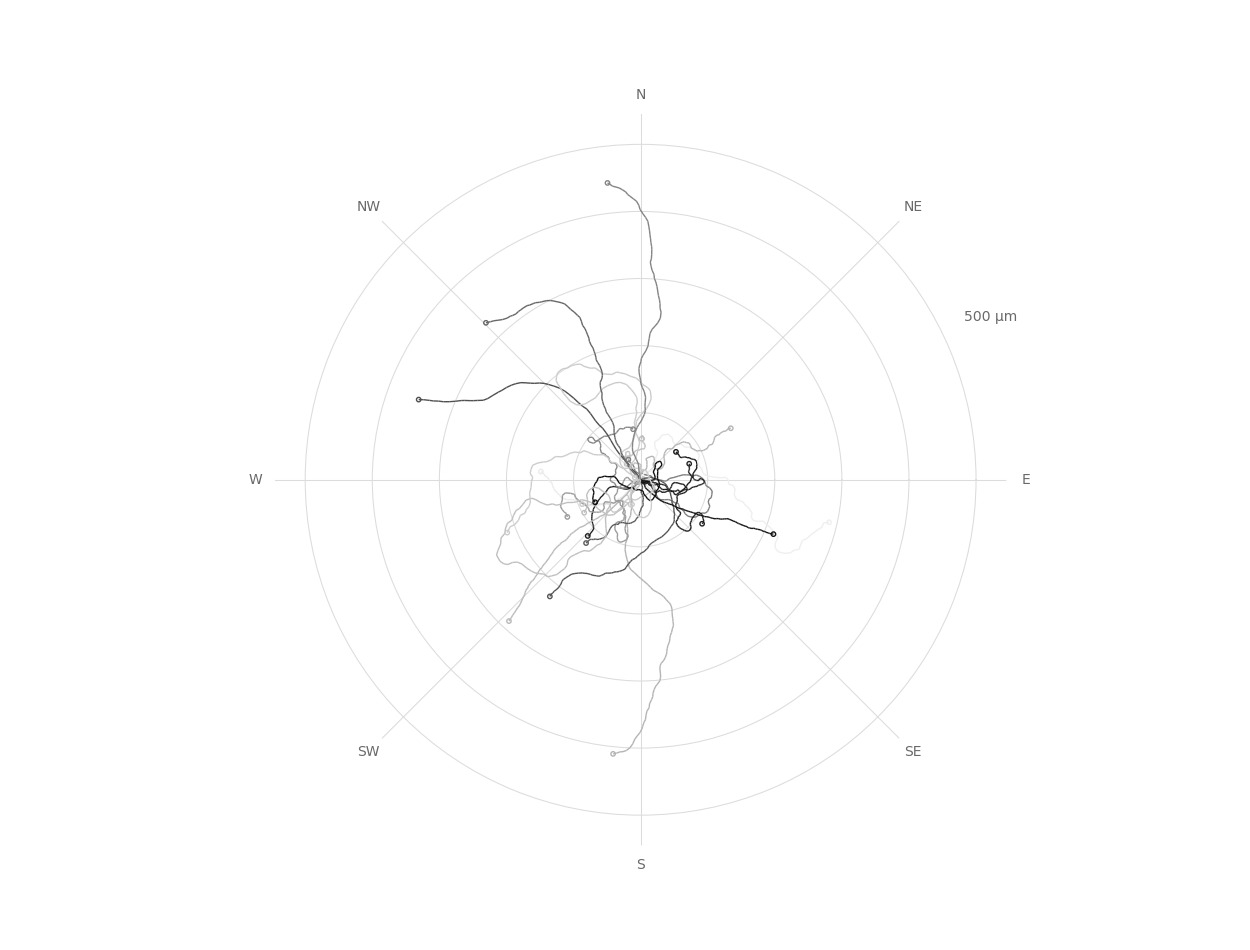

In [ ]:
result = reconstruct(spots, color='random greys', align_at_start=True, editable=True)
result.to_editable_html()

In [ ]:
# %matplotlib widget

# mpl.rcParams['animation.embed_limit'] = 50


# anim = result.animate(speed=2.0, interval=20, controls=True, mode="jshtml")
# anim

# # result.figure.show()

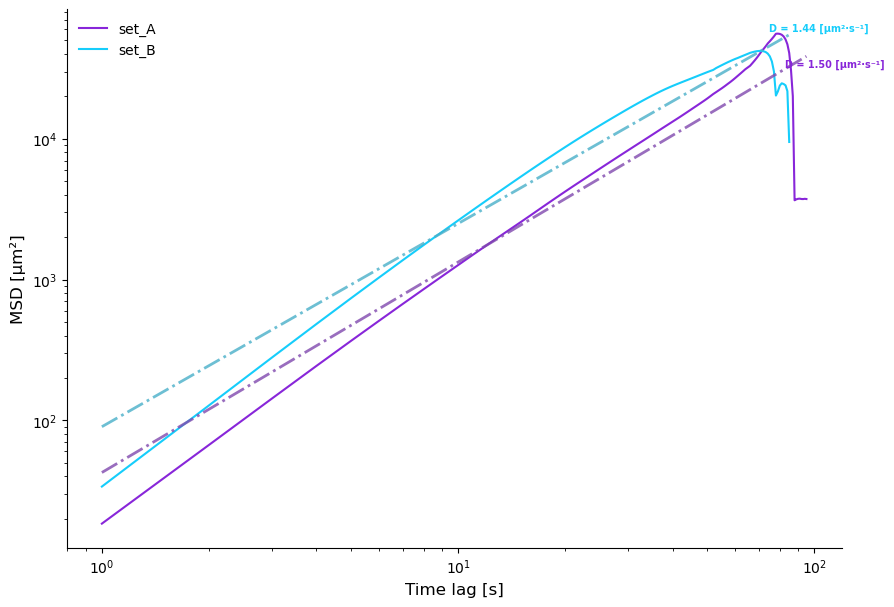

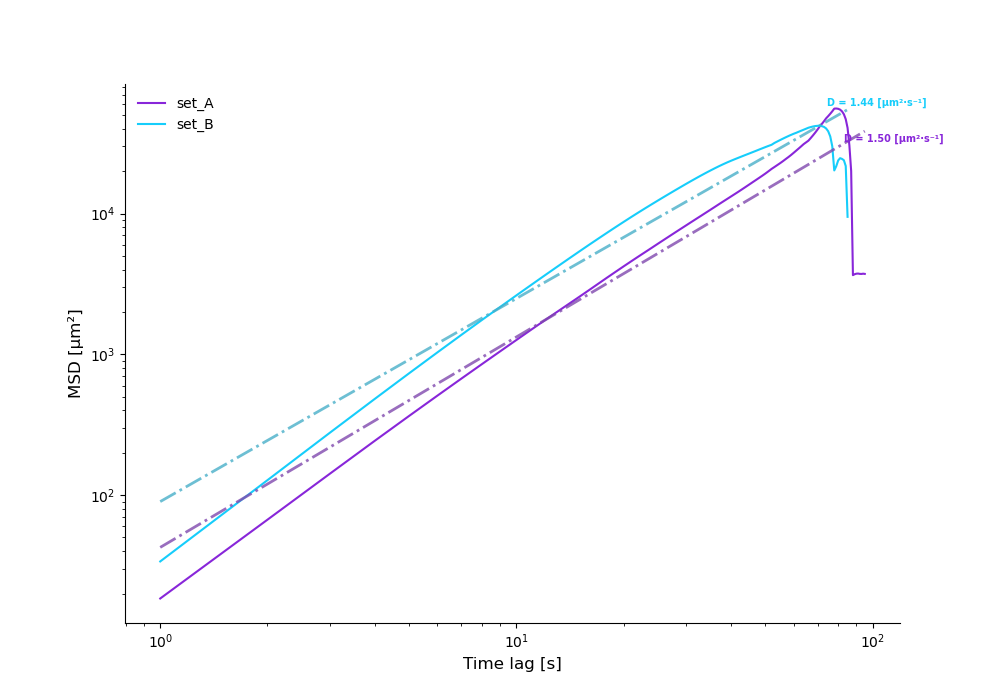

In [ ]:
import src.plot.time.lags as lags_module

import importlib
importlib.reload(lags_module)

msd = lags_module.msd

msd(
    spots, 
    grouping_level='highest', 
    # categories={'set': ['set_B']},
    log=True,
    linear_fit=True,
)

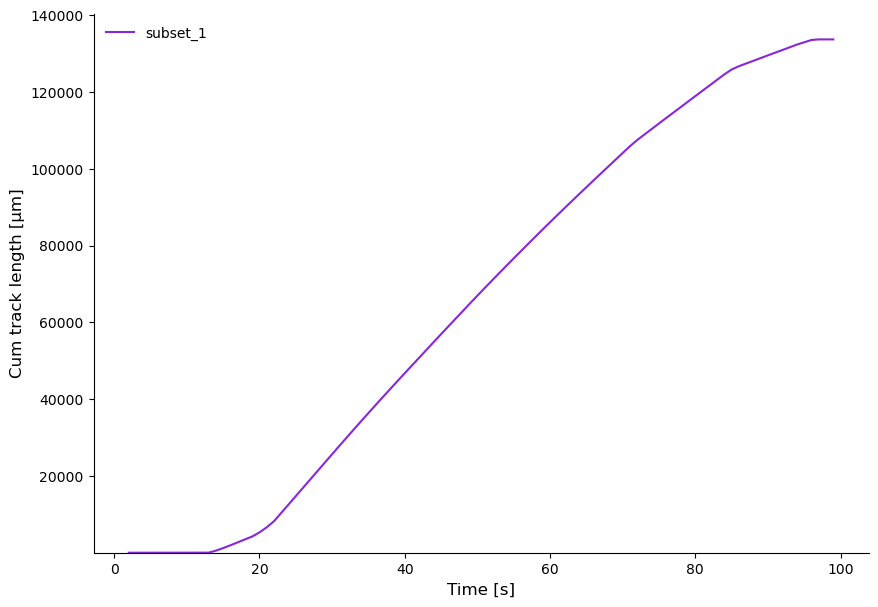

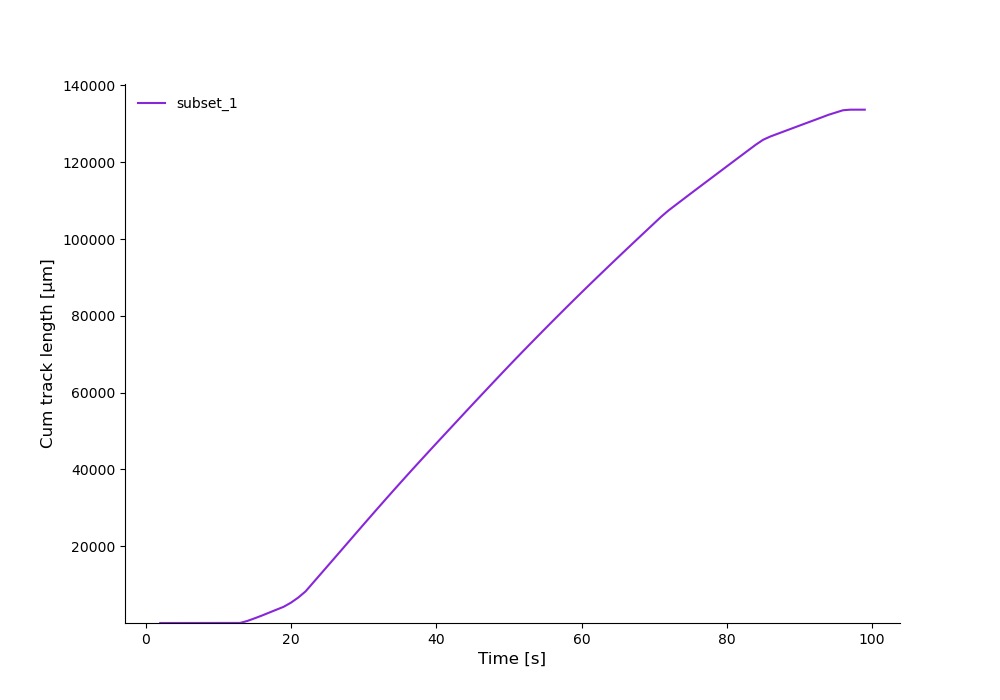

In [ ]:
import src.plot.time.series as series_module

import importlib
importlib.reload(series_module)

time_series = series_module.time_series



time_series(
    spots,
    metric='cum_track_length',
    grouping_level='set', 
)

In [ ]:
import matplotlib.pyplot as plt
plt.close('all')